# The PyTorch bridge: calling the Rust core from a training loop

PRIN keeps every numerical result in Rust. This notebook shows the machinery
that makes that invisible from PyTorch: the DLPack tensor boundary, the
`torch.autograd.Function` bridge that carries gradients back into Rust-owned
code, float64 `gradcheck`, Rust-side parameter checkpointing, and a complete
Adam training loop.

**Runtime budget:** under 60 s on a CPU-only machine (measured at authoring
time: see the last cell). No GPU, no network, no datasets.

Everything is seeded. PRIN has no hidden RNG — stochastic construction goes
through the Rust `Seed` type, and the layer constructors take explicit
`seed_counter` / `seed_key` halves.

In [1]:
import time

import matplotlib.pyplot as plt
import torch

import prin
import prin.dlpack as dlpack
from prin.nn import (
    DiscreteDeltaThetaGammaLayer,
    HierarchicalResonanceLayer,
    ResonanceLayer,
)
from prin.nn._bridge import apply_rust_bridge

%matplotlib inline
torch.manual_seed(0)

print(f"prin {prin.__version__} / core {prin.core_version()} / torch {torch.__version__}")
print(f"public symbols: {len(prin.__all__)}")

prin 0.3.0 / core 0.3.0 / torch 2.11.0+cu128
public symbols: 175


## 1. DLPack: the tensor boundary

`prin.dlpack` is the smallest possible demonstration of the boundary: send a
tensor into Rust, do something trivial, get a tensor back. `round_trip` is the
identity, `negate` is a one-element kernel, and `negate_batched` does a list of
them in one call.

The bridge requires **contiguous** CPU tensors and raises a typed error
otherwise rather than silently copying or reinterpreting a strided view.

In [2]:
t = torch.arange(6, dtype=torch.float64).reshape(2, 3)
print("round_trip identical:", bool(torch.equal(dlpack.round_trip(t), t)))
print("negate identical:    ", bool(torch.equal(dlpack.negate(t), -t)))

batched = dlpack.negate_batched([t, t.T.contiguous()])
print("negate_batched shapes:", [tuple(b.shape) for b in batched])

try:
    dlpack.negate_batched([t, t.T])  # t.T is a strided view
except ValueError as exc:
    print("non-contiguous ->", type(exc).__name__, exc)

round_trip identical: True
negate identical:     True
negate_batched shapes: [(2, 3), (3, 2)]
non-contiguous -> ValueError non-contiguous DLPack tensors are not supported by this bridge


The round trip is a **copy**, not an alias: the returned tensor has its own
storage. Bidirectional zero-copy kernel input is gated on a CubeCL
external-memory API that does not exist yet (Deferred Validation DV-030,
partially closed by WP-036E under Project Plan amendment #43), so the honest
statement about this boundary today is *one copy in, one copy out*.

In [3]:
print("same storage:", dlpack.round_trip(t).data_ptr() == t.data_ptr())
print("shapes preserved:", tuple(dlpack.round_trip(t).shape) == tuple(t.shape))

same storage: False
shapes preserved: True


## 2. The autograd bridge

`prin.nn` modules are ordinary `torch.nn.Module`s. `HierarchicalResonanceLayer`
runs a δ/θ/γ band network in Rust; `apply_rust_bridge` is what stitches the
Rust forward and its VJP into the autograd graph, so the returned tensor has a
`grad_fn` and gradients reach the input.

This is a demonstration of the mechanism, not a measurement: the layer is tiny
(4/8/32 oscillators over a 64-wide input) so it runs in milliseconds.

In [4]:
layer = HierarchicalResonanceLayer(
    n_delta=4, n_theta=8, n_gamma=32, n_dims=64, n_steps=3, seed_counter=0, seed_key=7
)
print("output width (n_total):", layer.n_total)
print("torch parameters:      ", [(n, tuple(p.shape)) for n, p in layer.named_parameters()])

x = torch.randn(4, 64, requires_grad=True)
y = layer(x)
print("forward:", tuple(y.shape), y.dtype, "grad_fn:", type(y.grad_fn).__name__)

y.sum().backward()
print("input grad norm:", round(float(x.grad.norm()), 6))
print("pac_depth grads:", {n: round(float(p.grad), 6) for n, p in layer.named_parameters()})

output width (n_total): 44
torch parameters:       [('pac_depth_dt', ()), ('pac_depth_tg', ())]
forward: (4, 44) torch.float32 grad_fn: AddBackward0


input grad norm: 7.208961
pac_depth grads: {'pac_depth_dt': 176.0, 'pac_depth_tg': 176.0}


The layer can also hand back the oscillator phases, which is what you want when
you are inspecting binding rather than training.

In [5]:
amplitudes, phases = layer(torch.randn(4, 64), return_phase=True)
print("amplitudes:", tuple(amplitudes.shape), "phases:", tuple(phases.shape))
print("phase range: [%.4f, %.4f]  (expected within [0, 2pi))" % (phases.min(), phases.max()))

amplitudes: (4, 44) phases: (4, 44)
phase range: [0.0081, 6.2643]  (expected within [0, 2pi))


## 3. Float64 gradcheck

Testing Standards §2 requires `torch.autograd.gradcheck` in float64 for every
`autograd.Function` bridge. The same check runs in the test suite; here it is
visible.

The layer is shrunk to 2/4/8 oscillators over a 16-wide input because
`gradcheck` re-runs the forward once per input element — a numerical
Jacobian. This is the standard gradcheck trade-off, not a claim about the
production configuration.

In [6]:
small = HierarchicalResonanceLayer(
    n_delta=2, n_theta=4, n_gamma=8, n_dims=16, n_steps=2, seed_counter=0, seed_key=3
).to(torch.float64)
x64 = torch.randn(2, 16, dtype=torch.float64, requires_grad=True)

started = time.perf_counter()
ok = torch.autograd.gradcheck(small, (x64,), eps=1e-6, atol=1e-4, rtol=1e-3)
print(f"gradcheck (float64): {ok} in {time.perf_counter() - started:.2f}s")

gradcheck (float64): True in 13.00s


## 4. Rust-owned parameter state

The numerically active weights of a bridge layer live in Rust, so the
checkpoint format is an opaque byte blob rather than a `state_dict` of tensors.
`rust_state_dict()` serializes it and `load_rust_state_dict()` restores it into
a compatible layer — the two layers below are constructed with different seeds
and produce identical output after the transfer.

In [7]:
source = HierarchicalResonanceLayer(
    n_delta=4, n_theta=8, n_gamma=32, n_dims=64, n_steps=3, seed_counter=0, seed_key=1
)
target = HierarchicalResonanceLayer(
    n_delta=4, n_theta=8, n_gamma=32, n_dims=64, n_steps=3, seed_counter=0, seed_key=2
)

probe = torch.randn(4, 64)
print("before transfer, identical:", bool(torch.equal(source(probe), target(probe))))

blob = source.rust_state_dict()
print("checkpoint:", type(blob).__name__, len(blob), "bytes")

target.load_rust_state_dict(blob)
print("after transfer, identical: ", bool(torch.equal(source(probe), target(probe))))

before transfer, identical: False
checkpoint: bytes 22791 bytes


after transfer, identical:  True


## 5. A complete training loop

Nothing about the loop is special — that is the point. A Rust-backed layer drops
into an ordinary `torch.optim` loop.

The target here is deliberately trivial (drive the band amplitudes toward zero)
so the loop runs in well under a second. It demonstrates that gradients reach
the optimizer, not that the task is meaningful.

20 Adam steps in 2.05s
loss 0.159288 -> 0.175220
learned: {'pac_depth_dt': -0.683034, 'pac_depth_tg': -0.683034}


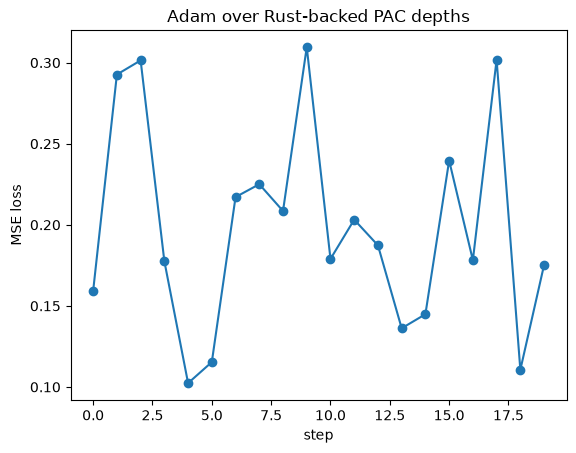

In [8]:
model = HierarchicalResonanceLayer(
    n_delta=4, n_theta=8, n_gamma=32, n_dims=64, n_steps=3, seed_counter=0, seed_key=11
)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-2)
target = torch.zeros(8, model.n_total)

torch.manual_seed(0)
losses = []
started = time.perf_counter()
for _ in range(20):
    optimizer.zero_grad()
    loss = torch.nn.functional.mse_loss(model(torch.randn(8, 64)), target)
    loss.backward()
    optimizer.step()
    losses.append(loss.detach().item())
elapsed = time.perf_counter() - started

print(f"20 Adam steps in {elapsed:.2f}s")
print(f"loss {losses[0]:.6f} -> {losses[-1]:.6f}")
print("learned:", {n: round(float(p.detach()), 6) for n, p in model.named_parameters()})

plt.plot(losses, marker="o")
plt.xlabel("step")
plt.ylabel("MSE loss")
plt.title("Adam over Rust-backed PAC depths")
plt.show()
plt.close()

## 6. Parameter mirrors and the E4 gradient pattern

Every trainable layer in `prin.nn` exposes its parameters through
`layer.parameters()` and populates `.grad` after `loss.backward()`. The Rust
bridge is the numerical owner of the forward pass; the PyTorch parameters are
value-preserving mirrors that carry the PRINet-3.0 names and shapes. An
exactly-zero term in `forward()` (`p - p.detach()` summed over all parameters)
ensures gradients flow to every mirror without perturbing the forward value
(the E4 mirror pattern).

| Layer | `parameters()` | `forward` has `grad_fn` | `backward` populates `.grad` |
|---|---|---|---|
| `HierarchicalResonanceLayer` | 2 (`pac_depth_dt`, `pac_depth_tg`) | yes | yes |
| `ResonanceLayer` | 5 (coupling, decay, modulation, base_frequency, input_proj) | yes | yes |
| `DiscreteDeltaThetaGamma` | 13 | yes | yes |
| `DiscreteDeltaThetaGammaLayer` | 15 (projections + dynamics mirrors) | yes | yes |

The Rust-side parameters are reachable through `rust_state_dict()` /
`load_rust_state_dict()` for checkpointing. Verify with your own eyes rather
than trusting a table:

In [9]:
torch.manual_seed(0)
probe = torch.randn(4, 64)

for factory in (
    lambda: HierarchicalResonanceLayer(n_delta=4, n_theta=8, n_gamma=32, n_dims=64, n_steps=3),
    lambda: ResonanceLayer(n_oscillators=44, n_dims=64, n_steps=3),
    lambda: DiscreteDeltaThetaGammaLayer(n_delta=4, n_theta=8, n_gamma=32, n_dims=64, n_steps=3),
):
    m = factory()
    out = m(probe)
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(
        f"{type(m).__name__:32s} out={tuple(out.shape)} "
        f"grad_fn={str(out.grad_fn is not None):5s} trainable_params={trainable}"
    )

HierarchicalResonanceLayer       out=(4, 44) grad_fn=True  trainable_params=2
ResonanceLayer                   out=(4, 44) grad_fn=True  trainable_params=6776
DiscreteDeltaThetaGammaLayer     out=(4, 44) grad_fn=True  trainable_params=7399


## Summary

| Topic | API |
|---|---|
| Tensor boundary | `prin.dlpack.round_trip` / `negate` / `negate_batched` |
| Autograd bridge | `prin.nn._bridge.apply_rust_bridge`, `prin.nn.HierarchicalResonanceLayer` |
| Gradient verification | `torch.autograd.gradcheck` in float64 |
| Rust-side checkpointing | `rust_state_dict()` / `load_rust_state_dict()` |
| Training | ordinary `torch.optim.Adam` over `layer.parameters()` |

What to read next:

* the [Architecture Guide](https://prin.readthedocs.io/en/latest/architecture.html)
  for the full data-flow picture, including where DLPack conversion happens;
* `01_oscillosim_quickstart.ipynb` for the dynamics side of the same Rust core;
* the [Parity Report](https://prin.readthedocs.io/en/latest/parity_report.html)
  for the measured tolerances these bridges are held to.

In [10]:
print(f"notebook 04 complete — prin {prin.__version__}, torch {torch.__version__}")

notebook 04 complete — prin 0.3.0, torch 2.11.0+cu128
